# Rename-proof logic consensus & per-error-type sensitivity: `method.py` demo

This notebook walks through the **driver script `method.py`** from iteration-3 experiment 8 of a study of **gold-free metrics for NL→FOL (autoformalization) output quality**. Changes to the original code are kept to a minimum.

**Research question.** Given a sentence and a candidate first-order-logic formula, and **no gold formula**, can a cheap score predict whether the formula is faithful to the text?

**Method (PEER_HYB consensus).** Several model families translate the same sentence independently. A candidate *agrees* with a peer formula if z3 proves the two equivalent after aligning their vocabularies. There are two alignment maps:
* **ALIGN**: aligns predicates by name similarity (CamelCase-token Jaccard or trigram Dice), plus merge/split bridges;
* **NF-anchored**: a *name-free* predicate bijection built from structural signatures and text anchors;
* **HYB** = ALIGN **OR** NF.

The consensus score is `c = 1 − (#agreeing peers)/(#peers)`. **Higher means an error is more likely.**

**What `method.py` does.**
1. `run()` runs 13 resumable pipeline stages as subprocesses: scoring, pre-registration freezes, analyses, GPU judges and tests.
2. `build_output()` joins the per-item scores with the labels and writes `method_out.json`. It covers four datasets:
   * **E**: real LLM and symbolic generator outputs, with panel and solver labels;
   * **PERTURB**: typed mutants of gold-like formulas, with 27 metrics each;
   * **exp-D rewrites**: meaning-preserving rewrites;
   * **screen items and probes**.

**Headline results** (full data, from the artifact):
* **Stratified AUROC on E:** c_align 0.741, c_hyb 0.738, c_nf 0.686.
* **Rename test (pre-registered):** neither rename-invariant variant passed; **the R_COMP read uses ALIGN**.
* **Within-base AUROC on PERTURB:** PEER+TEXT 0.948, c_align 0.866, c_hyb 0.847, local judges about 0.65.

**What this demo runs.** The pipeline stages need the full repository (GPU, OpenRouter, about 60 MB of intermediate files), so the demo only *lists* them. It then runs the real `build_output()` on a curated **92-example** subset (`mini_demo_data.json`) and re-derives the consensus scores from the stored z3 pair verdicts. It finishes by plotting how well each metric separates CORRECT from ERROR rows.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, sklearn, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

## Imports
This is the original import block of `method.py`, followed by the extra libraries used only for the results and plots at the end.

In [2]:
from __future__ import annotations

import argparse
import json
import math
import subprocess
import sys
from pathlib import Path

from loguru import logger

# --- notebook-only additions (results table / plots)
import types
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

## Data loading
`mini_demo_data.json` holds a subset of **every input file that `build_output()` reads**. It is a single dict, `files`, keyed by each file's original path relative to the repository root (for example `results/per_item_hyb_E.jsonl`). The loader tries the GitHub copy first and falls back to a local file.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_An1uy2kF2SjZ/round-3/experiment-8/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print({k: len(v) for k, v in data["files"].items()})

{'results/selection.json': 10, 'results/analysis_perturb.json': 2, 'results/per_item_hyb_E.jsonl': 39, 'data/exp5/E_blind.jsonl': 39, 'results/pairs_E.jsonl': 254, 'results/perturb_scores.jsonl': 38, 'data/perturb_rows.jsonl': 36, 'results/per_item_screen_hyb.jsonl': 15, 'data/screen/screen_adjudicated_labels.json': 5, 'data/invariance_items.json': 5, 'data/screen/screen_items.json': 9, 'data/exp5/screen_probes.json': 5}


## Configuration
These settings control how many rows of each dataset go into `build_output()`. The demo is cheap: it only joins data, and everything finishes in seconds. The values are therefore set to use **all** rows in the mini subset. Set any of them to a small number (e.g. `2`) for a smoke test.

The original script has no row caps. On the full data it processes 8,507 E rows, 5,402 PERTURB rows and 1,869 screen rows.

`RUN_PIPELINE_STAGES=False` means the 13 subprocess stages are printed, not executed. Their scripts (`src/*.py`) and the GPU, API and z3 infrastructure are not part of this demo.

In [5]:
MAX_E_ROWS = 39          # rows of results/per_item_hyb_E.jsonl to process     (original: all 8,507)
MAX_PERTURB_ROWS = 38    # rows of results/perturb_scores.jsonl to process     (original: all 5,402 = 4,234 mutants + 868 controls + 300 bases)
MAX_SCREEN_ROWS = 15     # rows of results/per_item_screen_hyb.jsonl to process (original: all 1,870)
RUN_PIPELINE_STAGES = False  # True only inside the full artifact repository (needs src/, .venv, GPU, OpenRouter key)

## Setup: paths and logging
This is copied from the original script. `ROOT` is the notebook's directory. `PY` would be the repository's virtual-env interpreter that the stages run under.

In [6]:
ROOT = Path(".").resolve()   # original: Path(__file__).resolve().parent
RES = ROOT / "results"
PY = str(ROOT / ".venv" / "bin" / "python")
sys.path.insert(0, str(ROOT / "src"))

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")

2

## The pipeline: 13 resumable stages
Every stage is a subprocess that writes its results under `results/`. `DONE_MARK` lists the stages that **freeze** something:
* `freeze_a` writes the pre-registration for the HYB/NF selection;
* `freeze_b` writes the PERTURB pre-registration (thresholds, statistics, predictions);
* `s4` fits the S4 stack;
* `calib` builds the calibration set.

Once written, these files are never overwritten. Each pre-registration is frozen, and its SHA-256 recorded, **before** any label is joined. That order is what makes the selection "blind".

In [7]:
STAGES = [
    ("score", [[PY, "src/run_scoring.py", "E", "--stage", "all"], [PY, "src/run_scoring.py", "screen", "--stage", "all"]]),
    ("gate", [[PY, "src/gate_check.py"]]),
    ("freeze_a", [[PY, "src/freeze_prereg_hyb.py"]]),
    ("part_a", [[PY, "src/analyse_hyb.py"]]),
    ("calib", [[PY, "src/prep_calib.py"]]),
    ("api", [[PY, "src/run_api_perturb.py"]]),
    ("cpu_b", [[PY, "src/perturb_cpu.py"]]),
    ("gpu_b", [[PY, "src/perturb_gpu.py", "--which", "judges_disg,verb,nli"]]),
    ("s4", [[PY, "src/fit_s4_perturb.py"]]),
    ("freeze_b", [[PY, "src/freeze_prereg_perturb.py"]]),
    ("part_b", [[PY, "src/analyse_perturb.py"]]),
    ("part_c", [[PY, "src/typing_perturb.py"]]),
    ("tests", [[PY, "-m", "pytest", "-q", "-c", "pytest.ini", "tests"]]),
]
DONE_MARK = {"freeze_a": RES / "prereg_hyb.sha256", "freeze_b": RES / "prereg_perturb.sha256", "calib": ROOT / "data" / "E_calib_units.jsonl",
             "s4": RES / "s4_perturb_coefs.json"}


def run(start: str | None):
    go = start is None
    for name, cmds in STAGES:
        go = go or name == start
        if not go:
            continue
        if name in DONE_MARK and DONE_MARK[name].exists():
            logger.info(f"{name}: already done ({DONE_MARK[name].name}); frozen files are never overwritten")
            continue
        for c in cmds:
            logger.info(f"{name}: {' '.join(c[1:])}")
            subprocess.run(c, cwd=ROOT, check=True)

In [8]:
# Notebook: the stage scripts are not shipped with the demo, so by default we only print the plan run() would execute.
if RUN_PIPELINE_STAGES:
    run(None)
else:
    for name, cmds in STAGES:
        for c in cmds:
            print(f"{name:9s} {' '.join(c[1:])}")

score     src/run_scoring.py E --stage all
score     src/run_scoring.py screen --stage all
gate      src/gate_check.py
freeze_a  src/freeze_prereg_hyb.py
part_a    src/analyse_hyb.py
calib     src/prep_calib.py
api       src/run_api_perturb.py
cpu_b     src/perturb_cpu.py
gpu_b     src/perturb_gpu.py --which judges_disg,verb,nli
s4        src/fit_s4_perturb.py
freeze_b  src/freeze_prereg_perturb.py
part_b    src/analyse_perturb.py
part_c    src/typing_perturb.py
tests     -m pytest -q -c pytest.ini tests


## Standing in for `an_common` and the result files
`build_output()` uses three things from the repository's `an_common` module:
* `C.jl(path)`: reads a JSONL file;
* `C.sha256_file(path)`: hashes a pre-registration file;
* `C.DATA`: the data directory.

It also reads a few JSON files with `json.loads(path.read_text())`.

The small shim below serves all of these from `data["files"]`, keyed by the same relative paths. This is the only change to the data access. The configured row caps are applied here too. The pre-registration hashes are the real SHA-256 values of the frozen files.

In [9]:
_CAPS = {"results/per_item_hyb_E.jsonl": MAX_E_ROWS, "results/perturb_scores.jsonl": MAX_PERTURB_ROWS,
         "results/per_item_screen_hyb.jsonl": MAX_SCREEN_ROWS}

def _rel(p: Path) -> str:
    return Path(p).resolve().relative_to(ROOT).as_posix()

def _jl(p: Path) -> list[dict]:
    rows = data["files"].get(_rel(p), [])
    return rows[: _CAPS[_rel(p)]] if _rel(p) in _CAPS else rows

def _read_json(p: Path):
    return data["files"][_rel(p)]

C = types.SimpleNamespace(DATA=ROOT / "data", jl=_jl, sha256_file=lambda p: data["sha256"][_rel(p)])

## Output helper `s()`
Every score is written out as a string with 6 decimals. Missing or NaN values become `"NA"`, so that scores that are unavailable stay **visible** in the output instead of being silently dropped.

In [10]:
# ================================================================================================ method_out.json
def s(x) -> str:
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return "NA"
    if isinstance(x, bool):
        return str(x)
    if isinstance(x, float):
        return f"{x:.6f}"
    return str(x)

## `build_output()`: joining scores, labels and inputs
This is the original function, unchanged apart from path access, which now goes through the shim (`import an_common as C` is removed, and `json.loads(X.read_text())` becomes `_read_json(X)`). It builds four datasets:

1. **`E_heldout_candidates`**: real generator outputs (LLMs plus ccg2lambda). `output` is the adjudicated label (CORRECT, ERROR or UNPARSEABLE), and `metadata_y_R_AB` is the binary label from label tiers A/B. The ALIGN, NF and HYB consensus scores are `predict_c_score_*` (binary peer agreement) and `predict_g_score_*` (graded agreement over claim units).
2. **`PERTURB_suite`**: typed mutants (ADD, DROP, NEG, QUANT, SWAP, REV, CONN, BIND, RESTR, MEANING_RENAME …) and meaning-preserving controls. All **27 metrics** are included, among them the consensus scores, the pilot structural metrics, L2/L3 text metrics, SC-5, round-trip NLI, local and API judges and S4. Metrics that failed are marked `FAIL(...)` rather than dropped.
3. **`expD_rewrites_screen`**: meaning-preserving rewrites. Each rewrite inherits the label of its base.
4. **`screen_items_and_probes`**: the screen set used to fit thresholds, plus error probes.

`predict_frozen_invariant` is `NONE_ELIGIBLE`. The pre-registered rule froze neither HYB nor NF, because both failed the rename false-alarm test.

In [11]:
def build_output():
    # import an_common as C   -> notebook: C is the data shim defined above
    sel = _read_json(RES / "selection.json")
    frozen = sel.get("frozen_score")
    frozen_label = sel.get("frozen_variant") or "NONE_ELIGIBLE"
    blind = {r["row_key"]: r for r in C.jl(C.DATA / "exp5" / "E_blind.jsonl")}
    ds = []
    # ---- dataset E (development for the selection; real generator outputs)
    ex = []
    for r in C.jl(RES / "per_item_hyb_E.jsonl"):
        b = blind[r["row_key"]]
        e = {"input": json.dumps({"text": b["text"], "candidate_fol": b["candidate_fol"], "system": b["system"],
                                  "prompt_variant": b["prompt_variant"]}, ensure_ascii=False),
             "output": r["final_label"], "metadata_fold": "E", "metadata_row_key": r["row_key"], "metadata_sentence_id": r["sentence_id"],
             "metadata_stratum": r["stratum"], "metadata_label_tier": r["label_tier"], "metadata_y_R_AB": r["y_AB"],
             "metadata_system_class": r["system_class"], "metadata_coverage_status": r["coverage_status"], "metadata_n_peers": r["n_peers"],
             "predict_c_score_hyb": s(r["c_hyb"]), "predict_g_score_hyb": s(r["g_hyb"]), "predict_c_score_nf": s(r["c_nf"]),
             "predict_c_score_align": s(r["c_align"]), "predict_g_score_align": s(r["g_align"]), "predict_g_score_nf": s(r["g_nf"]),
             "predict_frozen_invariant": s(r.get(frozen)) if frozen else frozen_label}
        ex.append(e)
    ds.append({"dataset": "E_heldout_candidates", "examples": ex})
    # ---- PERTURB (mutants, controls, bases): every Part B metric
    pb = C.jl(RES / "perturb_scores.jsonl")
    A = _read_json(RES / "analysis_perturb.json")
    mets = A["metrics"]
    ex = []
    rows = {r["item_id"]: r for r in C.jl(C.DATA / "perturb_rows.jsonl")}
    for u in pb:
        is_base = u["key"].startswith("PB:")
        src = rows.get(u["item_id"]) if not is_base else None
        text = src["text"] if src else next(r["text"] for r in rows.values() if r["base_item_id"] == u["base"])
        e = {"input": json.dumps({"text": text, "candidate_fol": u["fol"]}, ensure_ascii=False),
             "output": "ERROR" if u["y"] == 1 else "CORRECT",
             "metadata_fold": "PERTURB_BASE" if is_base else ("PERTURB" if u["y"] == 1 else "PERTURB_CONTROL"),
             "metadata_key": u["key"], "metadata_base_item_id": u["base"], "metadata_operator": u["operator"],
             "metadata_op_fine": u["op_fine"], "metadata_control_type": u["control_type"], "metadata_polarity": u["polarity"],
             "metadata_matched_pair_id": u["matched_pair_id"], "metadata_subtype": u["subtype"], "metadata_base_status": u["base_status"],
             "metadata_base_endorsed": u.get("base_endorsed"),
             "predict_frozen_invariant": s(u.get(frozen)) if frozen else frozen_label}
        for m in mets:
            e[f"predict_{m}"] = s(u.get(m)) if u.get(m + "__status") != "fail" else ("FAIL(" + s(u.get(m)) + ")")
        e["predict_c_score_hyb"] = e.pop("predict_c_hyb", "NA")
        e["predict_g_score_hyb"] = e.pop("predict_g_hyb", "NA")
        e["predict_c_score_nf"] = e.pop("predict_c_nf", "NA")
        e["predict_c_score_align"] = e.pop("predict_c_align", "NA")
        ex.append(e)
    ds.append({"dataset": "PERTURB_suite", "examples": ex})
    # ---- screen items, exp D rewrites, probes (consensus variants)
    ex_rw, ex_sc = [], []
    labs = _read_json(C.DATA / "screen" / "screen_adjudicated_labels.json")
    inv = {x["rw_id"]: x for x in _read_json(C.DATA / "invariance_items.json")}
    items = {x["item_id"]: x for x in _read_json(C.DATA / "screen" / "screen_items.json")}
    probes = {f"PR:{p['probe']}:{p['base_item_id']}": p for p in _read_json(C.DATA / "exp5" / "screen_probes.json")}
    for r in C.jl(RES / "per_item_screen_hyb.jsonl"):
        k = r["key"]
        if k.startswith("M:"):
            continue
        if k.startswith("RW:"):
            x = inv[k[3:]]
            text, fol, fold = x["text"], x["candidate_fol"], "REWRITE_EXPD"
            out = labs.get(x["base_item_id"], {}).get("final_label") or "UNLABELLED"  # a meaning-preserving rewrite inherits its base label
            base = x["base_item_id"]
            extra = {"metadata_rewrite_family": x["family"], "metadata_base_item_id": base,
                     "metadata_base_label": labs.get(base, {}).get("final_label")}
        elif k.startswith("PR:"):
            p = probes[k]
            b = items[p["base_item_id"]]
            text, fol, fold, out = b["text"], p["fol"], "SCREEN_PROBE", "ERROR"
            extra = {"metadata_probe": p["probe"], "metadata_base_item_id": p["base_item_id"]}
        else:
            b = items.get(k)
            if b is None:
                continue
            text, fol, fold, out = b["text"], b["candidate_fol"], "SCREEN", r["label"] or "UNLABELLED"
            extra = {"metadata_track": b["track"], "metadata_system": b["system"]}
        e = {"input": json.dumps({"text": text, "candidate_fol": fol}, ensure_ascii=False), "output": out, "metadata_fold": fold,
             "metadata_key": k, "metadata_sentence_id": r["sentence_id"], **{kk: v for kk, v in extra.items() if v is not None},
             "predict_c_score_hyb": s(r["c_hyb"]), "predict_g_score_hyb": s(r["g_hyb"]), "predict_c_score_nf": s(r["c_nf"]),
             "predict_c_score_align": s(r["c_align"]), "predict_frozen_invariant": frozen_label if not frozen else s(r.get(frozen))}
        (ex_rw if fold == "REWRITE_EXPD" else ex_sc).append(e)
    ds.append({"dataset": "expD_rewrites_screen", "examples": ex_rw})
    ds.append({"dataset": "screen_items_and_probes", "examples": ex_sc})
    out = {"metadata": {"method_name": "PEER_HYB rename-invariant cross-family consensus + PERTURB per-error-type sensitivity",
                        "description": "Oriented scores (higher = more likely ERROR). E: real generator outputs with panel/solver labels "
                                       "(development for the HYB/NF selection). PERTURB: synthetic typed mutants/controls (never pooled "
                                       "with E). See README.md and results/.",
                        "selection": {k: sel[k] for k in ("frozen_variant", "note", "E_strat_auroc_R_AB")},
                        "prereg_hyb_sha256": C.sha256_file(RES / "prereg_hyb.json"),
                        "prereg_perturb_sha256": C.sha256_file(RES / "prereg_perturb.json"),
                        "predict_frozen_invariant": "NONE_ELIGIBLE = no rename-invariant variant passed the pre-registered rule; the R_COMP read uses ALIGN (predict_c_score_align)" if not frozen else frozen},
           "datasets": ds}
    (ROOT / "method_out.json").write_text(json.dumps(out, ensure_ascii=False))
    logger.info(f"method_out.json: {[(d['dataset'], len(d['examples'])) for d in ds]}")

## `main()`: the `output` command
This is the original CLI entry point. A notebook has no command line, so `parse_args` gets `["output"]` explicitly, which is equivalent to running `python method.py output`.

In [12]:
@logger.catch(reraise=True)
def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("cmd", choices=["run", "output"])
    ap.add_argument("--from", dest="start", default=None)
    a = ap.parse_args(["output"])   # original: ap.parse_args() (CLI)
    if a.cmd == "run":
        run(a.start)
        build_output()
    else:
        build_output()


main()
out = json.loads((ROOT / "method_out.json").read_text())
print(json.dumps(out["metadata"]["selection"], indent=1))

16:36:11|INFO   |method_out.json: [('E_heldout_candidates', 39), ('PERTURB_suite', 38), ('expD_rewrites_screen', 5), ('screen_items_and_probes', 10)]


{
 "frozen_variant": null,
 "note": "NEITHER ELIGIBLE: no rename-invariant consensus exists here; both reported as failed; the R_COMP read uses ALIGN.",
 "E_strat_auroc_R_AB": {
  "HYB": 0.7375072927473793,
  "NF-anchored": 0.6859960770958894,
  "ALIGN": 0.7414618757606236
 }
}


## The core metric, recomputed from z3 pair verdicts
To show where the `c_*` scores come from, we recompute them from the raw **candidate–peer pair verdicts** in `results/pairs_E.jsonl`. Each verdict records whether z3 found the two formulas equivalent under the ALIGN map (`align_eq`), the NF-anchored map (`nf_eq`), or either one (`hyb_eq`).

Consensus is `c_mode = 1 − (#peers with mode_eq True)/(#peers)`, as in `consensus_lib.consensus_score`. An UNKNOWN verdict (a z3 timeout) never counts as agreement. The recomputed values should match the stored ones.

In [13]:
pairs = pd.DataFrame(C.jl(RES / "pairs_E.jsonl"))
recomp = pairs.groupby("cand").agg(n=("peer", "size"), **{f"re_c_{m}": (f"{m}_eq", lambda v: 1 - (v == True).sum() / len(v)) for m in ("align", "nf", "hyb")})
stored = pd.DataFrame(C.jl(RES / "per_item_hyb_E.jsonl")).set_index("row_key")
cmp_ = recomp.join(stored[["n_peers", "c_align", "c_nf", "c_hyb", "final_label"]], how="inner")
for m in ("align", "nf", "hyb"):
    print(f"c_{m}: recomputed == stored for {np.isclose(cmp_[f're_c_{m}'], cmp_[f'c_{m}']).sum()}/{len(cmp_)} candidates")
cmp_.round(3).head(12)

c_align: recomputed == stored for 31/31 candidates
c_nf: recomputed == stored for 31/31 candidates
c_hyb: recomputed == stored for 31/31 candidates


,n,re_c_align,re_c_nf,re_c_hyb,n_peers,c_align,c_nf,c_hyb,final_label
06d25b5836ec904f|zeroshot_v1,9,1.000,1.000,1.000,9.0,1.000,1.000,1.000,ERROR
0876e1fa4ed30d4d|none,10,1.000,1.000,1.000,10.0,1.000,1.000,1.000,CORRECT
0ba03d0a7c9f3adc|none,11,0.909,0.909,0.909,11.0,0.909,0.909,0.909,CORRECT
2477a503ed1d836c|fewshot_v1,5,0.200,0.200,0.200,5.0,0.200,0.200,0.200,ERROR
2e2fa549de96cba4|fewshot_v1,10,1.000,1.000,1.000,10.0,1.000,1.000,1.000,ERROR
3282d21bbc75a56b|fewshot_v1,5,0.200,0.200,0.200,5.0,0.200,0.200,0.200,CORRECT
341b29cd82f0a6fd|fewshot_v1,6,0.167,0.167,0.167,6.0,0.167,0.167,0.167,CORRECT
40e8a6243dec7709|fewshot_v1,9,1.000,1.000,1.000,9.0,1.000,1.000,1.000,ERROR
411afa7cffbfa1c7|fewshot_v1,8,1.000,1.000,1.000,8.0,1.000,1.000,1.000,ERROR
432639fcde97ac6b|fewshot_v1,9,0.889,1.000,0.889,9.0,0.889,1.000,0.889,CORRECT


## Results and visualisation
The tables and plots below summarise `method_out.json` on the demo subset:
1. **E**: the consensus scores for each candidate of each sentence, with their labels, and an AUROC for each score (ERROR vs CORRECT, R_AB label).
2. **PERTURB**: AUROC of each of the 27 metrics for separating typed mutants (ERROR) from bases and controls (CORRECT). This follows the *within-base* design of the full study, restricted to the two bases in the subset.
3. **Per-operator** mean score of the three consensus variants. Note that c_nf scores `MEANING_RENAME` like a correct formula, because it is name-free by design.

⚠️ These estimates come from roughly 40 rows each and are **for illustration only**. The artifact's full-data numbers are listed alongside for comparison.

{'E_heldout_candidates': 39, 'PERTURB_suite': 38, 'expD_rewrites_screen': 5, 'screen_items_and_probes': 10}

=== E candidates (higher score = more likely ERROR) ===
   metadata_stratum                        system       output  c_score_align  c_score_nf  c_score_hyb  g_score_hyb
0              CTRL                    ccg2lambda        ERROR           1.00        1.00         1.00         1.00
1              CTRL        llama-3.3-70b-instruct        ERROR           0.20        0.20         0.20         0.11
2              CTRL        llama-3.3-70b-instruct  UNPARSEABLE           1.00        1.00         1.00         1.00
3              CTRL         llama-3.1-8b-instruct        ERROR           0.20        0.20         0.20         0.11
4              CTRL          qwen3-235b-a22b-2507  UNPARSEABLE           1.00        1.00         1.00         1.00
5              CTRL          qwen3-235b-a22b-2507        ERROR           0.17        0.17         0.17         0.09
6              CTRL  mi


PERTURB AUROC on demo subset (30 mutants vs 8 bases/controls):
g_score_hyb                 0.967
c_score_hyb                 0.967
g_nf                        0.967
c_score_nf                  0.967
c_score_align               0.867
g_align                     0.858
rt_nli_min_local            0.719
p_peer_text                 0.704
rt_nli_fwd_local            0.698
l3_z3                       0.667
rt_nli_min_alt_local        0.665
p_text                      0.646
judge_local_qwen8b_disg     0.635
S4_local                    0.625
rt_nli_bwd_local            0.606
judge_local_llama8b_disg    0.604
rt_embed_cos_local          0.590
l2_bow                      0.569
judge_cheap_disg            0.533
pilot_joint_conflict        0.533
pilot_dangling              0.508
pilot_shape_incons          0.500
sc5_local_entropy           0.500
sc5_local_eq_frac           0.500
parse_fail                  0.500
pilot_arity_incons          0.500
rt_nli_contra_local         0.410

Mean consensus sc

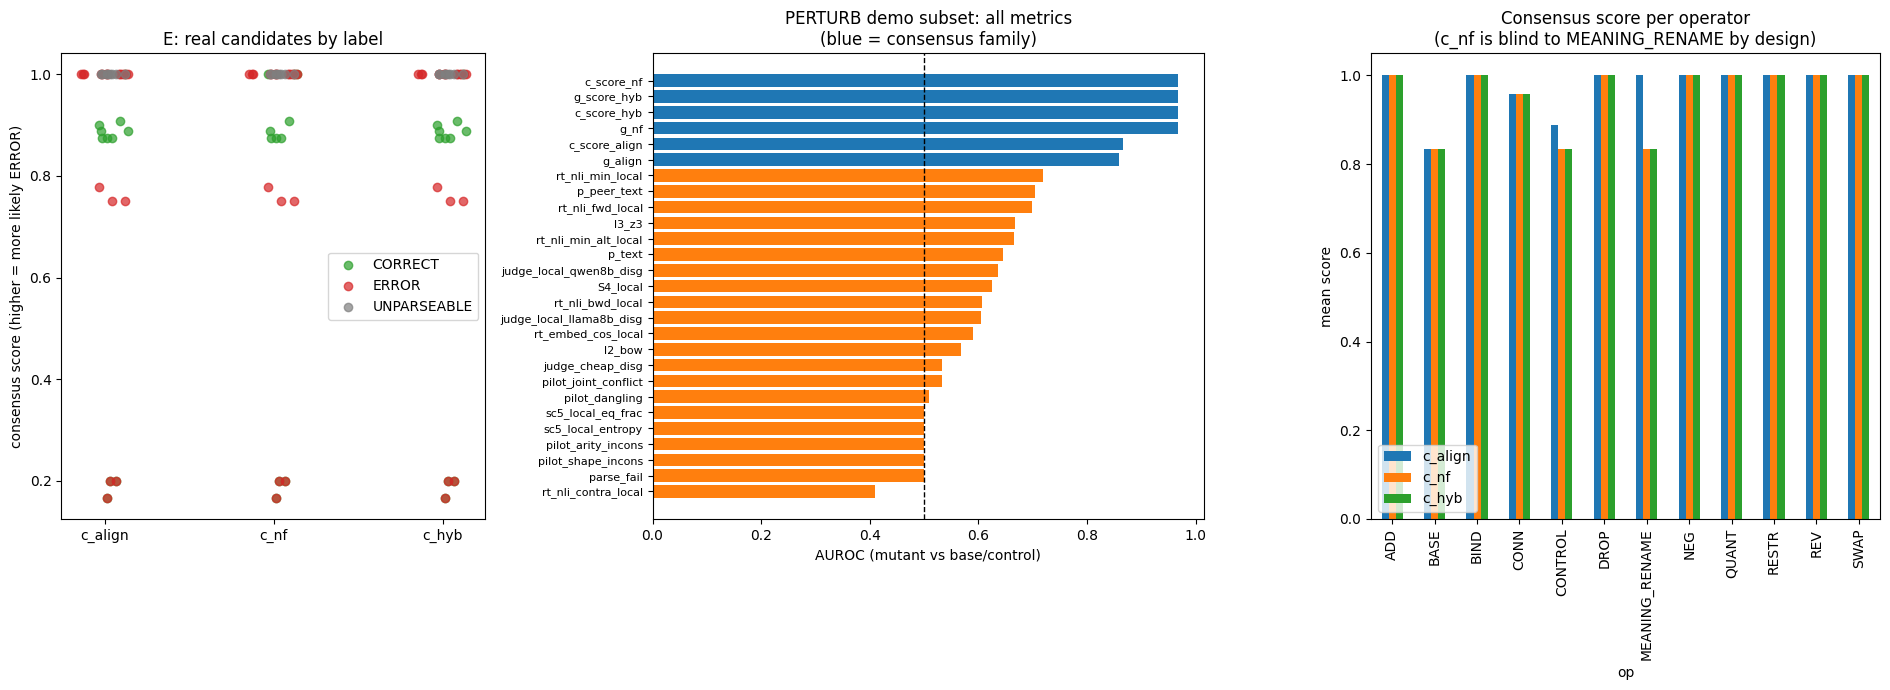

In [14]:
def _f(v):
    try: return float(v)
    except (TypeError, ValueError): return np.nan

D = {d["dataset"]: pd.DataFrame(d["examples"]) for d in out["datasets"]}
print({k: len(v) for k, v in D.items()})

# ---------- 1. E: real generator outputs
E = D["E_heldout_candidates"].copy()
E["text"] = E["input"].map(lambda x: json.loads(x)["text"][:60])
E["system"] = E["input"].map(lambda x: json.loads(x)["system"].split("/")[-1][:28])
E["fol"] = E["input"].map(lambda x: json.loads(x)["candidate_fol"][:70])
cols = ["predict_c_score_align", "predict_c_score_nf", "predict_c_score_hyb", "predict_g_score_hyb"]
for c in cols: E[c] = E[c].map(_f)
pd.set_option("display.width", 220); pd.set_option("display.max_colwidth", 70)
print("\n=== E candidates (higher score = more likely ERROR) ===")
print(E[["metadata_stratum", "system", "output"] + cols].rename(columns=lambda c: c.replace("predict_", "")).round(2).to_string())

Ey = E[E["metadata_y_R_AB"].notna()]
e_auc = {c.replace("predict_", ""): roc_auc_score(Ey["metadata_y_R_AB"].astype(int), Ey[c])
         for c in cols if Ey["metadata_y_R_AB"].nunique() == 2}   # AUROC needs both classes
full_e = out["metadata"]["selection"]["E_strat_auroc_R_AB"]
print(f"\nE AUROC on demo subset (n={len(Ey)} labelled LLM rows):", {k: round(v, 3) for k, v in e_auc.items()})
print("E stratified AUROC, full data (artifact):", {k: round(v, 3) for k, v in full_e.items()})

# ---------- 2. PERTURB: every metric, ERROR (mutants) vs CORRECT (bases + controls)
P = D["PERTURB_suite"].copy()
yP = (P["output"] == "ERROR").astype(int)
mcols = [c for c in P.columns if c.startswith("predict_") and c != "predict_frozen_invariant"]
p_auc = {}
for c in mcols:
    v = P[c].map(_f)
    ok = v.notna()
    if ok.sum() > 3 and yP[ok].nunique() == 2:
        p_auc[c.replace("predict_", "")] = roc_auc_score(yP[ok], v[ok])
p_auc = pd.Series(p_auc).sort_values()
print(f"\nPERTURB AUROC on demo subset ({yP.sum()} mutants vs {(1 - yP).sum()} bases/controls):")
print(p_auc.sort_values(ascending=False).round(3).to_string())

# ---------- 3. per operator mean consensus score
P["op"] = P["metadata_operator"].fillna(P["metadata_fold"].str.replace("PERTURB_", ""))
op_tab = P.assign(**{c: P[c].map(_f) for c in ["predict_c_score_align", "predict_c_score_nf", "predict_c_score_hyb"]}) \
          .groupby("op")[["predict_c_score_align", "predict_c_score_nf", "predict_c_score_hyb"]].mean()
print("\nMean consensus score per PERTURB operator / control:")
print(op_tab.rename(columns=lambda c: c.replace("predict_c_score_", "c_")).round(2).to_string())

# ---------- plots
fig, ax = plt.subplots(1, 3, figsize=(19, 7), gridspec_kw={"width_ratios": [1, 1.3, 1.2]})
lab_col = {"CORRECT": "tab:green", "ERROR": "tab:red", "UNPARSEABLE": "tab:gray"}
for i, c in enumerate(cols[:3]):
    for lab, g in E.groupby("output"):
        ax[0].scatter(np.full(len(g), i) + np.random.RandomState(0).uniform(-.15, .15, len(g)), g[c], c=lab_col.get(lab, "k"),
                      label=lab if i == 0 else None, alpha=.7)
ax[0].set_xticks(range(3)); ax[0].set_xticklabels(["c_align", "c_nf", "c_hyb"])
ax[0].set_ylabel("consensus score (higher = more likely ERROR)"); ax[0].set_title("E: real candidates by label"); ax[0].legend()

colors = ["tab:blue" if k in ("c_score_align", "c_score_nf", "c_score_hyb", "g_align", "g_nf", "g_score_hyb") else "tab:orange" for k in p_auc.index]
ax[1].barh(p_auc.index, p_auc.values, color=colors); ax[1].axvline(.5, ls="--", c="k", lw=1)
ax[1].set_xlabel("AUROC (mutant vs base/control)"); ax[1].set_title("PERTURB demo subset: all metrics\n(blue = consensus family)")
ax[1].tick_params(axis="y", labelsize=8)

op_tab.rename(columns=lambda c: c.replace("predict_c_score_", "c_")).plot.bar(ax=ax[2])
ax[2].legend(loc="lower left"); ax[2].set_ylabel("mean score"); ax[2].set_title("Consensus score per operator\n(c_nf is blind to MEANING_RENAME by design)")
plt.tight_layout(); plt.show()